<a href="https://colab.research.google.com/github/BrenaFreitas/Previsao_Churn_Clientes/blob/main/P1_Telco_Customer_Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Seção 1 - Contexto e Objetivos

## Telco customer churn

### Objetivo
O objetivo é entender o perfil dos clientes que optam pelo cancelamento do plano com a empresa Y. Para isso, realiza-se a Análise Exploratória dos Dados para saber as variáveis relevantes e a correlação entre elas e a variável 'churn'. Ao final, realiza-se o treinamento de modelo para previsão de clientes de 'churn'.

### Descrição do projeto desenvolvido

- Tema : Previsão de churn em serviços de assinatura

- Modelos : Random Forest e XGBoost

- Avaliação : F1-Score, Matriz de confusão , curvva ROC-AUC


### Variáveis

- Colunas : customerId, gender, SeniorCitizen, Partner,Depends,tenure, PhoneService, MultiplLines,InternetServive,OnlineSecurity,DeviceProtection , TechSupport, StreamingTV,StreamingMovies,
Contract,PaperlessBilling,PaymentMethod. MonthlyCharges,TotalCharges
- Alvo :  Churn

# Seção 2 - Importação e Carregamento dos dados

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 1er arquivo csv

data_p1 = pd.read_csv("/content/drive/MyDrive/ARQUIVOS-NOTE-DELL/ME/DATASETS/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [ ]:
data_p1.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
data_p1.groupby('Churn')['Dependents'].value_counts()

Churn  Dependents
0      No            3390
       Yes           1773
1      No            1543
       Yes            326
Name: count, dtype: int64

Ao agrupar os casos de churn com

In [ ]:
data_p1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


# Seção 3 - Pré processamento

In [ ]:
data_p1.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
data_p1['TotalCharges'] = pd.to_numeric(data_p1['TotalCharges'], errors='coerce')

In [ ]:
data_p1.duplicated().sum()

np.int64(0)

In [ ]:
data_p1.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


Ao aplicar a função de identificação de nulos no dataset, foi encontrado que a coluna 'TotalCharges' possui 11 valores nulos. Como a quantidade de linhas é pouco significante em relação ao total de linhas no conjunto de dados, vamos aplicar a função 'dropna' para exclusão das 11 linhas que possuem valores nulos.

In [ ]:
data_p1 =data_p1.dropna(subset=['TotalCharges']).copy()

In [ ]:
data_p1.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


Como a coluna customerID possui dados únicos para cada cliente, ela deve ser desconsiderado para análise e treinamento do modelo de dados, assim podemos escluir com a função 'drop'.

In [ ]:
data_p1.drop('customerID', axis=1, inplace=True)

In [ ]:
data_p1.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Variáveis categóricas

Utilizaremos o seaborn para visualização prévia das variáveis, para análise do equilíbrio no conjunto de dados

Os dados estão equilibrados para a coluna 'gênero' e possuem quantidades semelhantes entre homens e mulheres.

/tmp/ipykernel_15330/2152219118.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data_p1, x='gender', palette='viridis')


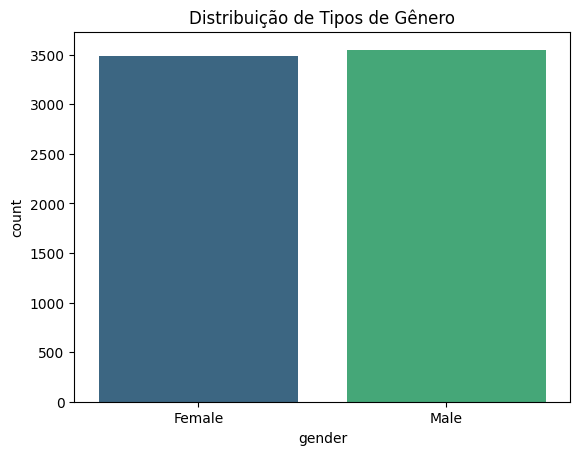

In [ ]:
# Exemplo para Gênero
sns.countplot(data=data_p1, x='gender', palette='viridis')
plt.title('Distribuição de Tipos de Gênero')
plt.show()

O gráfico de distribuição de serviços de internet, mostra que a maioria dos clientes possuem o serviço de  internet com fibra óptica. Alguns destes clientes não possuem o serviço de internet, como revelado na terceira coluna em verde claro.

/tmp/ipykernel_15330/1334440265.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data_p1, x='InternetService', palette='viridis')


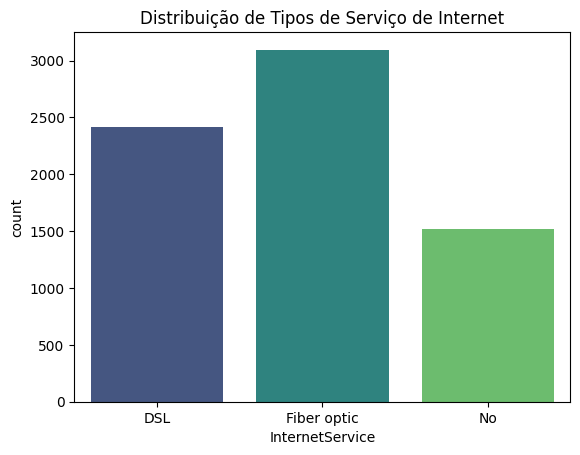

In [ ]:
# Exemplo para InternetService
sns.countplot(data=data_p1, x='InternetService', palette='viridis')
plt.title('Distribuição de Tipos de Serviço de Internet')
plt.show()

O gráfico de distribuião de métodos de pagamento mostra que a maioria dos clientes faz o pagamento via eletronic check.

/tmp/ipykernel_15330/33695207.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data_p1, x='PaymentMethod', palette='viridis')


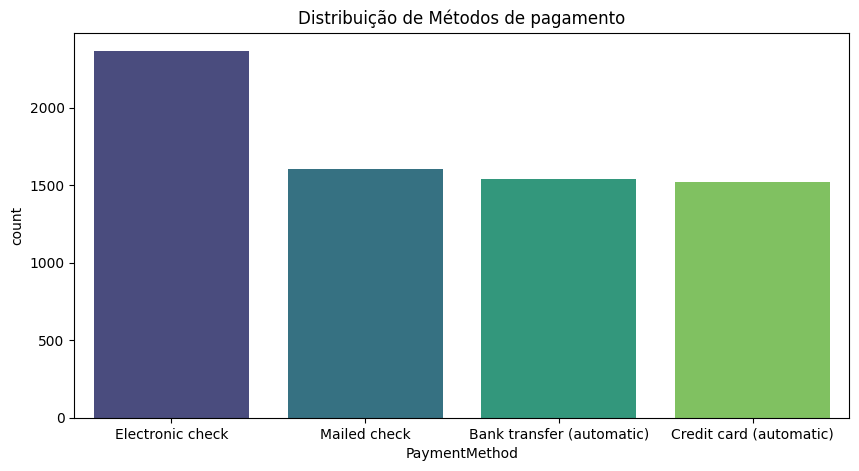

In [ ]:
plt.figure(figsize=(10, 5))

sns.countplot(data=data_p1, x='PaymentMethod', palette='viridis')
plt.title('Distribuição de Métodos de pagamento')
plt.show()

O gráfico mostra o desequilíbrio de dados de 'churn', o que pode influenciar nas previsões dos modelos.

/tmp/ipykernel_15330/3532675612.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data_p1, x='Churn', palette='viridis')


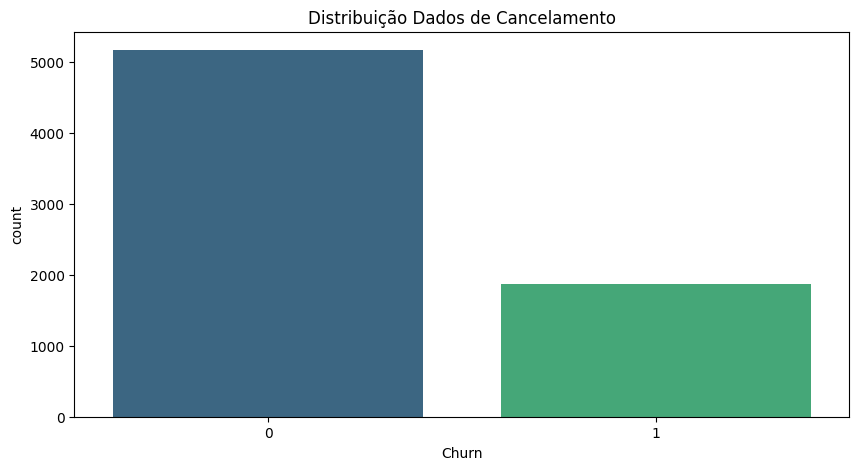

In [ ]:
plt.figure(figsize=(10, 5))

sns.countplot(data=data_p1, x='Churn', palette='viridis')
plt.title('Distribuição Dados de Cancelamento')
plt.show()

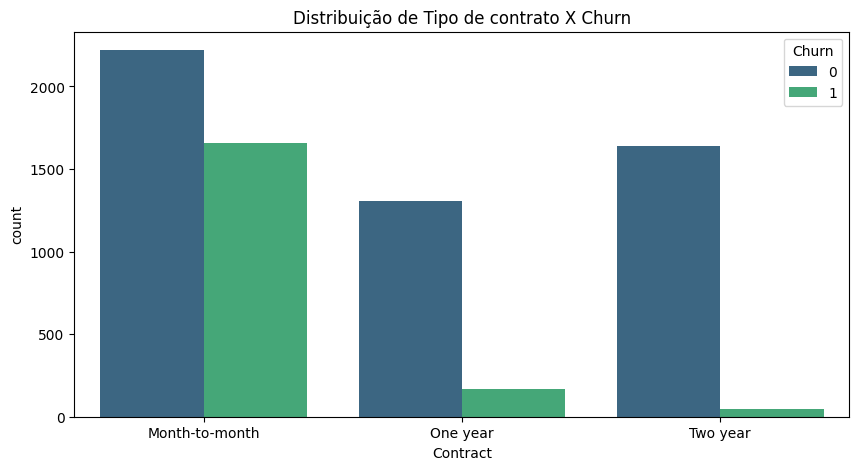

In [ ]:
plt.figure(figsize=(10, 5))

sns.countplot(data=data_p1, x='Contract', hue='Churn', palette='viridis')
plt.title('Distribuição de Tipo de contrato X Churn')
plt.show()

CLientes com contratos "month-to-month" têm uma maior taxa de cancelamento em comparação com os outros tipos de contrato - "one year" or "two-year". Assim, contratos com maior tempo de duração tendem a ter menor taxa de cancelamento.

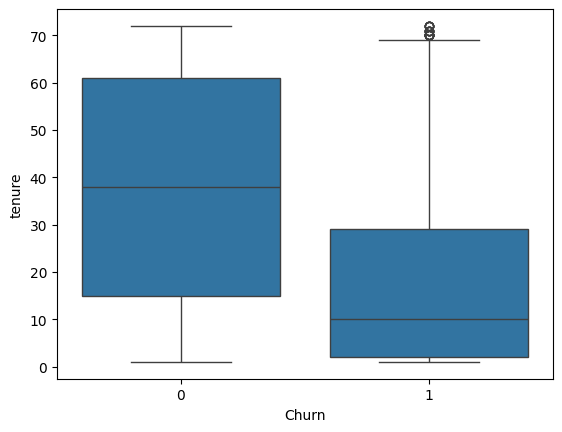

In [ ]:
sns.boxplot(x='Churn', y='tenure', data=data_p1)
plt.show()

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

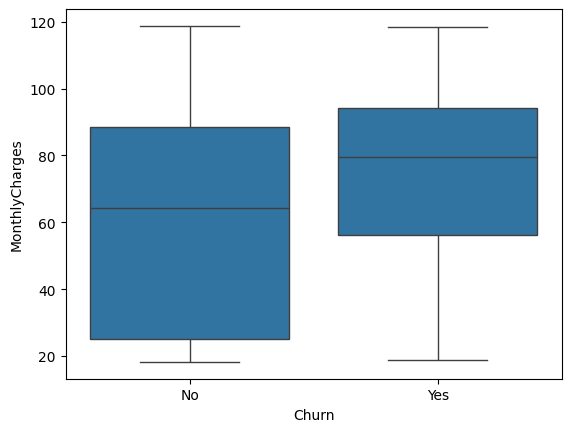

In [ ]:
# Comparar pagamento mensagm com
sns.boxplot(
    data=data_p1,
    x='Churn',
    y='MonthlyCharges'
)

Com o gráfico de distribuição de Churn, verifica-se que os valores estão desbalanceados, configurando um cenário em que a acurácia não é um métrica ideal a ser aplicada neste exemplo, visto que se torna uma métrica não confiável.

### Variáveis numéricas

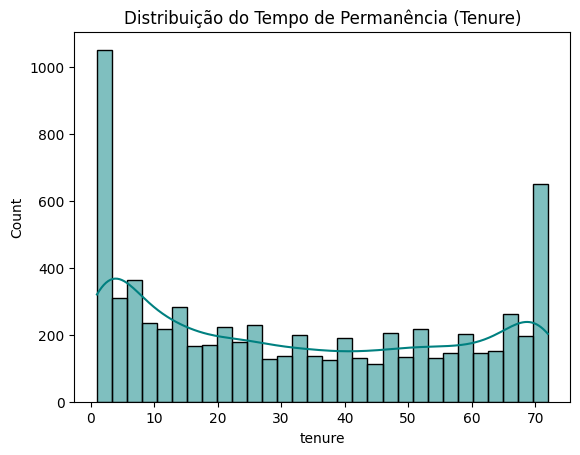

In [ ]:
# Histograma para Tenure
sns.histplot(data_p1['tenure'], bins=30, kde=True, color='teal')
plt.title('Distribuição do Tempo de Permanência (Tenure)')
plt.show()

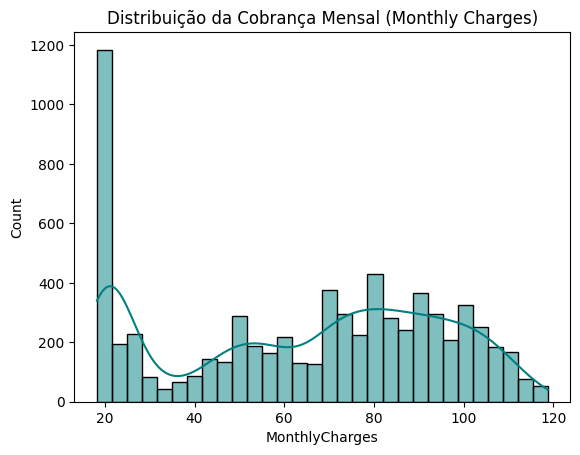

In [ ]:
# Histograma
sns.histplot(data_p1['MonthlyCharges'], bins=30, kde=True, color='teal')
plt.title('Distribuição da Cobrança Mensal (Monthly Charges)')
plt.show()

### Transformar variáveis categóricas

In [ ]:

# Encode Churn column
data_p1['Churn'] = data_p1['Churn'].map({
    'Yes': 1,
    'No': 0
})

In [ ]:
# Criando uma cópia para análise
df_analise = data_p1.copy()


binary_cols = ['Partner', 'Dependents', 'PhoneService']
for col in binary_cols:
    df_analise[col] = df_analise[col].map({'Yes': 1, 'No': 0})

# Converter 'gender'
df_analise['gender'] = df_analise['gender'].map({'Female': 1, 'Male': 0})

In [ ]:
df_analise['PaymentMethod'].value_counts()

,count
PaymentMethod,
Electronic check,2365
Mailed check,1604
Bank transfer (automatic),1542
Credit card (automatic),1521


In [ ]:
df_analise['Churn'].value_counts()

,count
Churn,
0,5163
1,1869


In [ ]:
# criar lista
cols_dependentes_internet = [
    'StreamingMovies', 'StreamingTV',
    'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport','Contract',
    'PaymentMethod'
]
# percorrer lista
for col in cols_dependentes_internet:
    df_analise[col] = df_analise[col].replace('No internet service', 'No')
# aplicar dummies
df_analise = pd.get_dummies(df_analise, columns=cols_dependentes_internet, drop_first=True)

In [ ]:
df_analise['MultipleLines'] = df_analise['MultipleLines'].replace('No phone service', 'No')

df_analise = pd.get_dummies(df_analise, columns=['MultipleLines'],drop_first=True)


In [ ]:
# Cria dummies sem drop_first
dummies = pd.get_dummies(df_analise['InternetService'])


In [ ]:
# Remove só a que você quer descartar (No)
dummies = dummies.drop(columns=['No'])

# Junta com o dataframe e remove a original
df_analise = pd.concat([df_analise.drop(columns=['InternetService']), dummies], axis=1)

In [ ]:
dummies


,DSL,Fiber optic
0,True,False
1,True,False
2,True,False
3,True,False
4,False,True
...,...,...
7038,True,False
7039,False,True
7040,True,False
7041,False,True


In [ ]:
from sklearn.preprocessing import LabelEncoder

# colunas com dummies

lista_dummies = [
    'StreamingMovies_Yes', 'StreamingTV_Yes',
    'OnlineSecurity_Yes', 'OnlineBackup_Yes',
    'DeviceProtection_Yes', 'TechSupport_Yes',
    'MultipleLines_Yes','PaperlessBilling','Churn','DSL',
    'Fiber optic','Contract_One year','Contract_Two year',
    'PaymentMethod_Credit card (automatic)',	'PaymentMethod_Electronic check',
    'PaymentMethod_Mailed check'
]

# label encoder
le = LabelEncoder()

for col in lista_dummies:
    df_analise[col] = le.fit_transform(df_analise[col])

In [ ]:
df_analise.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 24 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   gender                                 7032 non-null   int64  
 1   SeniorCitizen                          7032 non-null   int64  
 2   Partner                                7032 non-null   int64  
 3   Dependents                             7032 non-null   int64  
 4   tenure                                 7032 non-null   int64  
 5   PhoneService                           7032 non-null   int64  
 6   PaperlessBilling                       7032 non-null   int64  
 7   MonthlyCharges                         7032 non-null   float64
 8   TotalCharges                           7032 non-null   float64
 9   Churn                                  7032 non-null   int64  
 10  StreamingMovies_Yes                    7032 non-null   int64  
 11  Streaming

In [ ]:
df_analise.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,DeviceProtection_Yes,TechSupport_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,MultipleLines_Yes,DSL,Fiber optic
0,1,0,1,0,1,0,1,29.85,29.85,0,...,0,0,0,0,0,1,0,0,1,0
1,0,0,0,0,34,1,0,56.95,1889.50,0,...,1,0,1,0,0,0,1,0,1,0
2,0,0,0,0,2,1,1,53.85,108.15,1,...,0,0,0,0,0,0,1,0,1,0
3,0,0,0,0,45,0,0,42.30,1840.75,0,...,1,1,1,0,0,0,0,0,1,0
4,1,0,0,0,2,1,1,70.70,151.65,1,...,0,0,0,0,0,1,0,0,0,1


# Análise Exploratória

/tmp/ipykernel_2546/2037567326.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_analise,x='Churn' , palette='viridis')


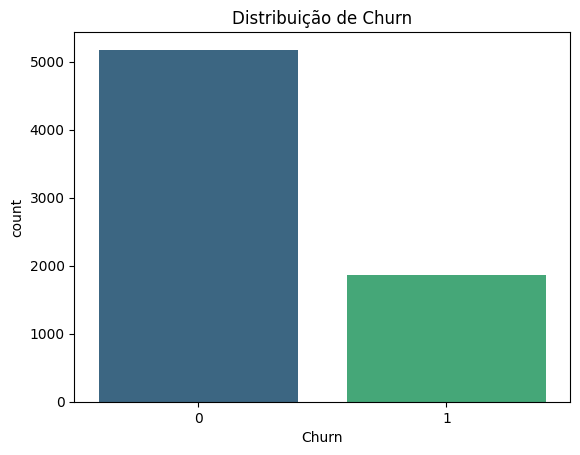

In [ ]:
sns.countplot(data=df_analise,x='Churn' , palette='viridis')
plt.title('Distribuição de Churn')
plt.show()

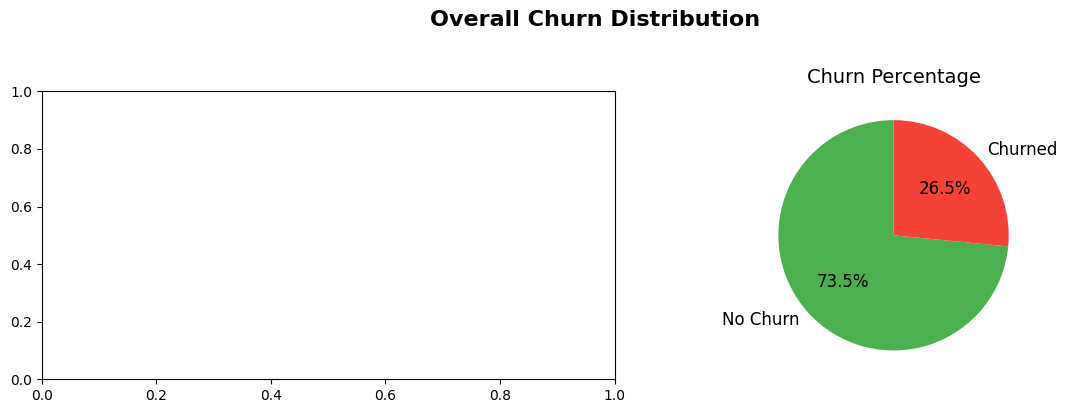

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

churn_counts = df_analise['Churn'].value_counts()
axes[1].pie(churn_counts, labels=['No Churn', 'Churned'],
            autopct='%1.1f%%', colors=['#4CAF50', '#F44336'],
            startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Churn Percentage', fontsize=14)

plt.suptitle('Overall Churn Distribution', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Matriz de correlação

In [ ]:
# Calcula a correlação (Pearson por padrão)
matriz_corr = df_analise.corr(numeric_only=True)

# Ver os números
print(matriz_corr)

                                         gender  SeniorCitizen   Partner  \
gender                                 1.000000       0.001819  0.001379   
SeniorCitizen                          0.001819       1.000000  0.016957   
Partner                                0.001379       0.016957  1.000000   
Dependents                            -0.010349      -0.210550  0.452269   
tenure                                -0.005285       0.015683  0.381912   
PhoneService                           0.007515       0.008392  0.018397   
PaperlessBilling                       0.011902       0.156258 -0.013957   
MonthlyCharges                         0.013779       0.219874  0.097825   
TotalCharges                          -0.000048       0.102411  0.319072   
Churn                                  0.008545       0.150541 -0.149982   
StreamingMovies_Yes                    0.010105       0.119842  0.118108   
StreamingTV_Yes                        0.007124       0.105445  0.124483   
OnlineSecuri

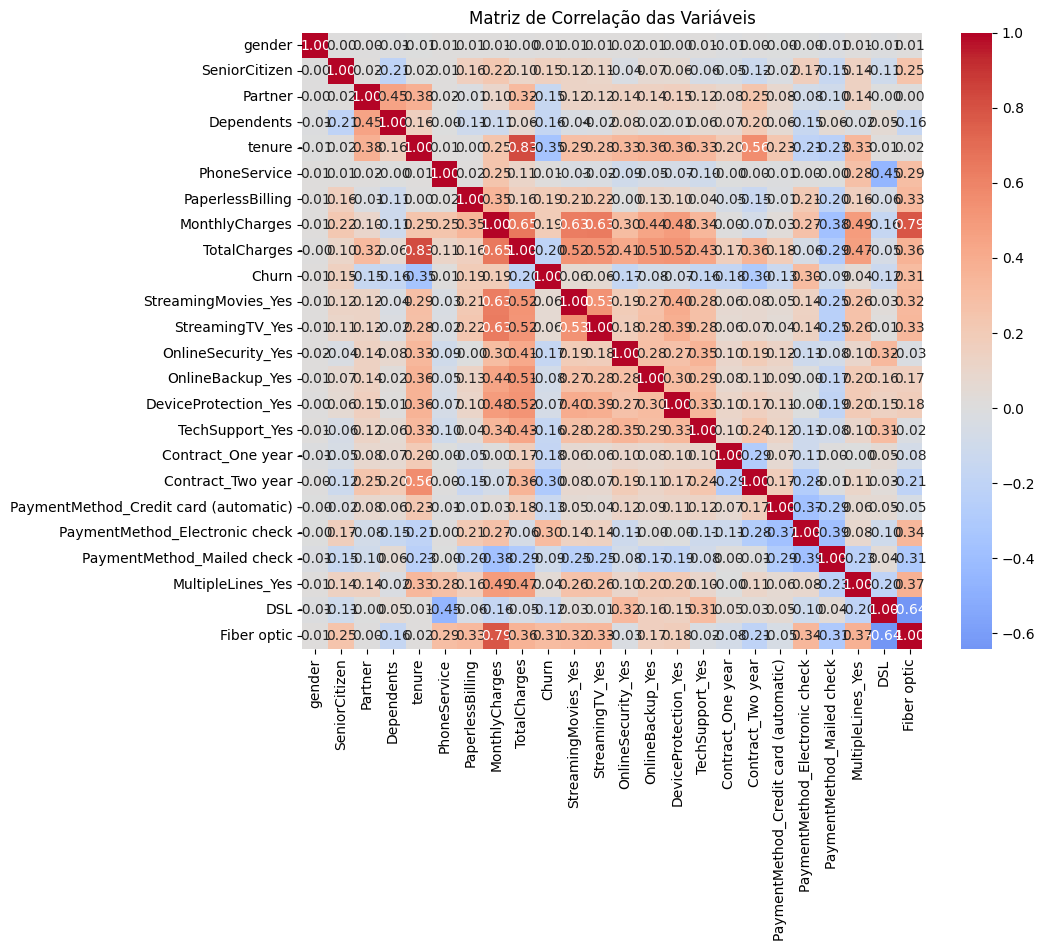

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Matriz de Correlação das Variáveis')
plt.show()

In [ ]:
print('Summary Statistics for Key Numerical Features:')
df_analise[['tenure', 'MonthlyCharges', 'TotalCharges']].describe().round(2)

Summary Statistics for Key Numerical Features:


,tenure,MonthlyCharges,TotalCharges
count,7032.00,7032.00,7032.00
mean,32.42,64.80,2283.30
std,24.55,30.09,2266.77
min,1.00,18.25,18.80
25%,9.00,35.59,401.45
50%,29.00,70.35,1397.48
75%,55.00,89.86,3794.74
max,72.00,118.75,8684.80


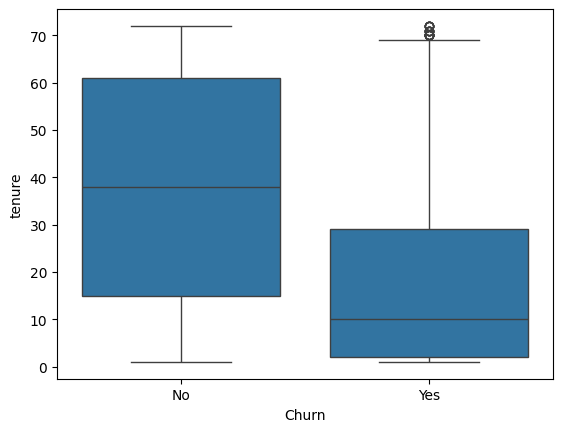

In [ ]:
sns.boxplot(x='Churn', y='tenure', data=df_analise)
plt.show()

Os usuários com maior tempo de permanência tendem a não cancelarem o plano ('churn'). Existe alguns outliers para usuários que cancelam o plano da operadora, se estão a mais de 70 meses.

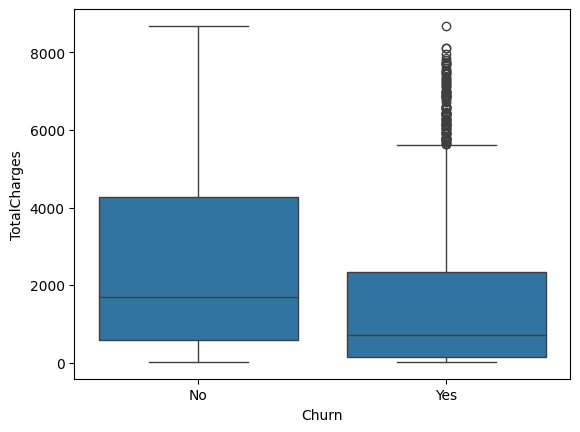

In [ ]:
sns.boxplot(x='Churn', y='TotalCharges', data=df_analise)
plt.show()

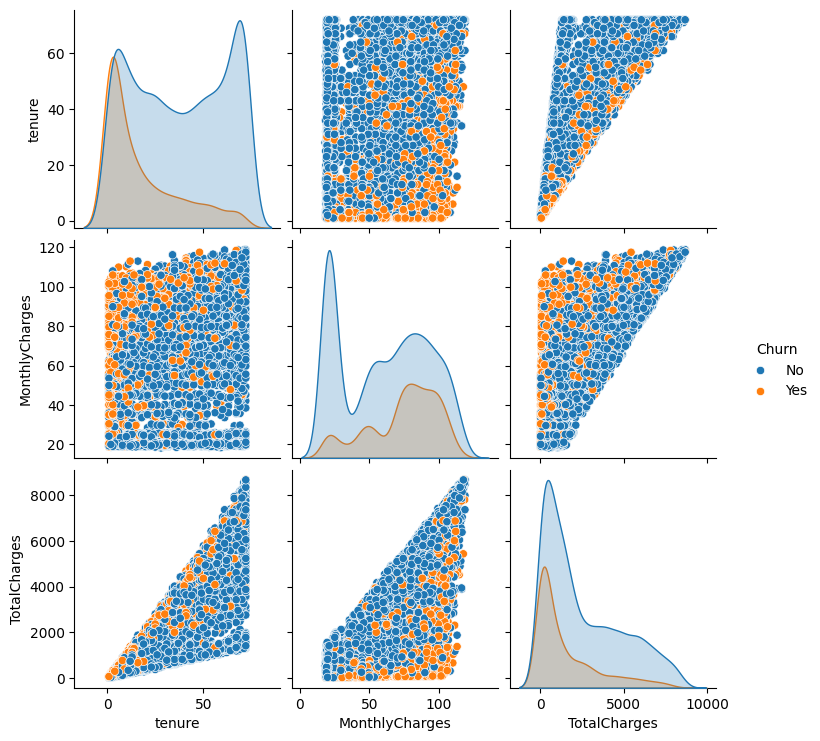

In [ ]:
sns.pairplot(df_analise[['tenure','MonthlyCharges','TotalCharges','Churn']], hue='Churn')
plt.show()

# Dividir base de dados - treinamento e teste

In [ ]:
# Separar o valor de previsão y dos atributos X
X = df_analise.drop('Churn', axis=1)
y = df_analise['Churn']

In [ ]:
X

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,StreamingMovies_Yes,...,DeviceProtection_Yes,TechSupport_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,MultipleLines_Yes,DSL,Fiber optic
0,1,0,1,0,1,0,1,29.85,29.85,0,...,0,0,0,0,0,1,0,0,1,0
1,0,0,0,0,34,1,0,56.95,1889.50,0,...,1,0,1,0,0,0,1,0,1,0
2,0,0,0,0,2,1,1,53.85,108.15,0,...,0,0,0,0,0,0,1,0,1,0
3,0,0,0,0,45,0,0,42.30,1840.75,0,...,1,1,1,0,0,0,0,0,1,0
4,1,0,0,0,2,1,1,70.70,151.65,0,...,0,0,0,0,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,0,1,1,24,1,1,84.80,1990.50,1,...,1,1,1,0,0,0,1,1,1,0
7039,1,0,1,1,72,1,1,103.20,7362.90,1,...,1,0,1,0,1,0,0,1,0,1
7040,1,0,1,1,11,0,1,29.60,346.45,0,...,0,0,0,0,0,1,0,0,1,0
7041,0,1,1,0,4,1,1,74.40,306.60,0,...,0,0,0,0,0,0,1,1,0,1


# Random Forest Classifier

### Passo 1

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

X_train

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,StreamingMovies_Yes,...,DeviceProtection_Yes,TechSupport_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,MultipleLines_Yes,DSL,Fiber optic
3946,1,0,0,0,9,0,0,58.50,539.85,1,...,1,1,0,0,0,0,1,0,1,0
3394,0,0,0,0,26,1,0,61.55,1581.95,0,...,0,0,1,0,0,1,0,1,1,0
1635,1,0,0,0,3,1,1,69.95,220.45,1,...,1,0,1,0,0,1,0,0,1,0
4088,0,0,0,0,7,1,0,73.60,520.00,0,...,0,0,0,0,0,1,0,1,0,1
1886,0,0,1,1,67,1,1,60.40,3953.70,0,...,1,1,0,1,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3778,0,0,0,0,3,1,0,50.40,137.25,0,...,0,0,0,0,0,0,0,1,1,0
5199,1,0,0,0,51,1,1,111.50,5703.25,1,...,1,1,1,0,0,1,0,1,0,1
5235,0,0,0,0,9,1,1,81.15,784.45,0,...,0,0,0,0,0,1,0,1,0,1
5399,1,0,0,0,50,1,0,19.75,989.05,0,...,0,0,1,0,0,0,0,0,0,0


In [ ]:
y_train

,Churn
1695,0
1095,0
3889,0
3667,0
2902,0
...,...
3772,1
5191,0
5226,0
5390,1


### Passo 2

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Criamos o modelo
# class_weight='balanced' ajuda se você tiver muito mais "ficou" do que "saiu"
clf_model = RandomForestClassifier( random_state=42, class_weight='balanced')

# Treino
clf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

### Passo 3

In [ ]:
# Predição direta (0 ou 1)
churn_preds = clf_model.predict(X_test)

# Probabilidade (ex: 0.85 de chance de sair)
# Útil para criar um ranking de clientes em risco
churn_probs = clf_model.predict_proba(X_test)[:, 1]

novas_predicoes = (churn_probs >= 0.35).astype(int)

In [ ]:
churn_probs

array([0.  , 0.11, 0.62, ..., 0.  , 0.32, 0.32])

### Passo 4: Avaliação de Resultados (Métricas de Classificação)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print(f"Acurácia Global: {accuracy_score(y_test, novas_predicoes):.2f}")
print("\nRelatório de Classificação:")
print(classification_report(y_test, novas_predicoes))

Acurácia Global: 0.76

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.87      0.80      0.83      1549
           1       0.54      0.66      0.60       561

    accuracy                           0.76      2110
   macro avg       0.70      0.73      0.71      2110
weighted avg       0.78      0.76      0.77      2110



### Passo 5: Visualização dos Resultados

### Matriz de confusão

Mostrar os 'verdadeiros positivos "verdadeiros negativos' 'falsos positivos' 'falsos negativos'

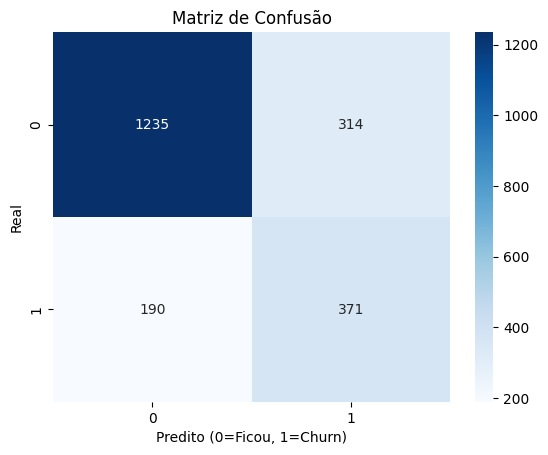

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, novas_predicoes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predito (0=Ficou, 1=Churn)')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.show()

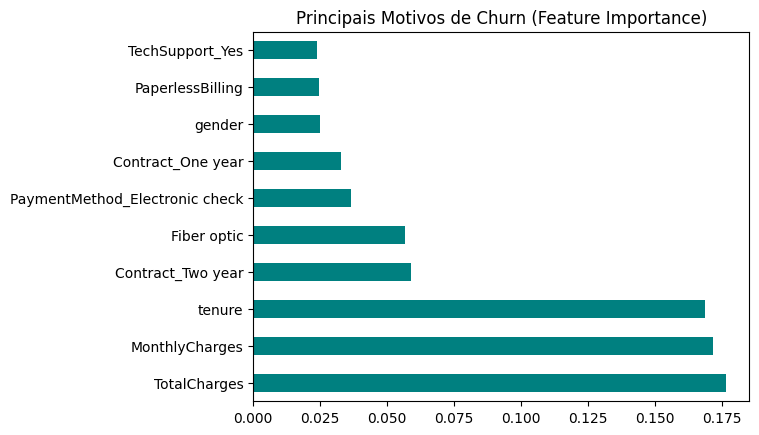

In [ ]:
import pandas as pd

importances = pd.Series(clf_model.feature_importances_, index=X_train.columns)
importances.nlargest(10).plot(kind='barh', color='teal')
plt.title('Principais Motivos de Churn (Feature Importance)')
plt.show()

# Modelo 2 Xboost

In [ ]:
import xgboost as xgb

In [ ]:
model2 = xgb.XGBClassifier(objective='multi:softmax', num_class=3)
model2.fit(X_train, y_train)
y_pred = model2.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f'Acurácia do modelo XGBoost: {accuracy:.2f}')

Acurácia do modelo XGBoost: 0.77


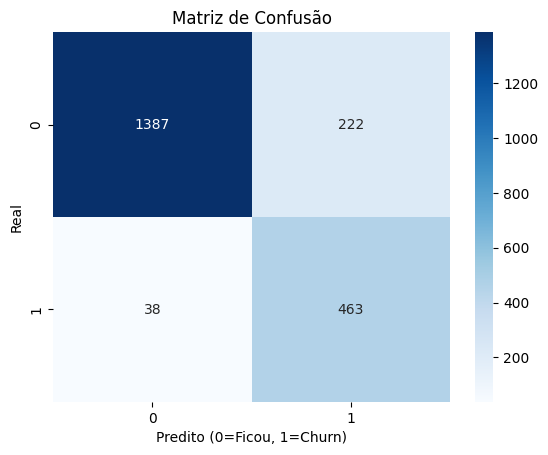

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_pred, novas_predicoes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predito (0=Ficou, 1=Churn)')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.show()

O modelo XBoost performou melhor do que o modelo Random Forest Classifier na identificação de clientes que cancelaram ou mantivera a assinatura com a empresa Telco.

Quais clientes o modelo mais erra?


# Ajuste de hiperparâmetros

Aplicação do RandomForestClassifier para encontrar os melhores parâmetros para o modelo RandomForest, utilizando a busca em grade (Grid Search)

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, None],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt']
}
grid_search = GridSearchCV(RandomForestClassifier(), param_grid, cv=5, n_jobs=-1)
grid_search.fit(X_train, y_train)
print(grid_search)

y_pred2 = grid_search.predict(X_test)
accuracy = accuracy_score(y_test, y_pred2)
print(f'Acurácia do modelo XGBoost: {accuracy:.2f}')

GridSearchCV(cv=5, estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'max_depth': [10, None], 'max_features': ['sqrt'],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]})
Acurácia do modelo XGBoost: 0.80


In [ ]:
print("Melhores hiperparâmetros:", grid_search.best_params_)
print(f"Melhor acurácia na validação cruzada: {grid_search.best_score_:.2f}")

from sklearn.metrics import classification_report, confusion_matrix

print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred2))

print("Matriz de Confusão:")
print(confusion_matrix(y_test, y_pred2))

Melhores hiperparâmetros: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 200}
Melhor acurácia na validação cruzada: 0.80

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.83      0.91      0.87      1549
           1       0.65      0.48      0.55       561

    accuracy                           0.79      2110
   macro avg       0.74      0.69      0.71      2110
weighted avg       0.78      0.79      0.78      2110

Matriz de Confusão:
[[1402  147]
 [ 290  271]]


              precision    recall  f1-score   support

           0       0.83      0.87      0.85      1549
           1       0.58      0.52      0.55       561

    accuracy                           0.77      2110
   macro avg       0.71      0.69      0.70      2110
weighted avg       0.77      0.77      0.77      2110

AUC-ROC: 0.694


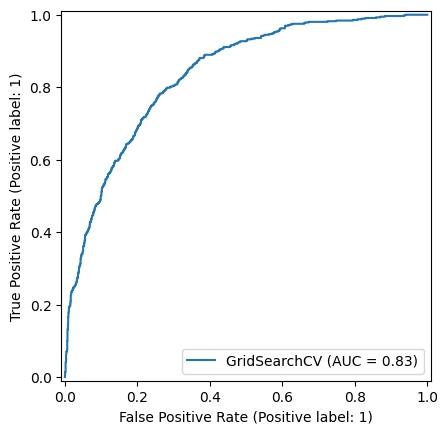

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score, RocCurveDisplay

print(classification_report(y_test, y_pred))
print(f"AUC-ROC: {roc_auc_score(y_test, y_pred2):.3f}")

RocCurveDisplay.from_estimator(grid_search, X_test, y_test)

Aplicação do XGBClassifier para encontrar os melhores parâmetros para o modelo XBoost, utilizando a busca em grade (Grid Search)

In [ ]:
bst = xgb.XGBClassifier(n_estimators=2, max_depth=2, learning_rate=1, objective='binary:logistic')
bst.fit(X_train, y_train)

preds = bst.predict(X_test)

In [ ]:

accuracy = accuracy_score(y_test, preds)
print(f'Acurácia do modelo XGBoost: {accuracy:.2f}')

Acurácia do modelo XGBoost: 0.78


              precision    recall  f1-score   support

           0       0.81      0.92      0.86      1549
           1       0.65      0.39      0.49       561

    accuracy                           0.78      2110
   macro avg       0.73      0.66      0.68      2110
weighted avg       0.77      0.78      0.76      2110

AUC-ROC: 0.657


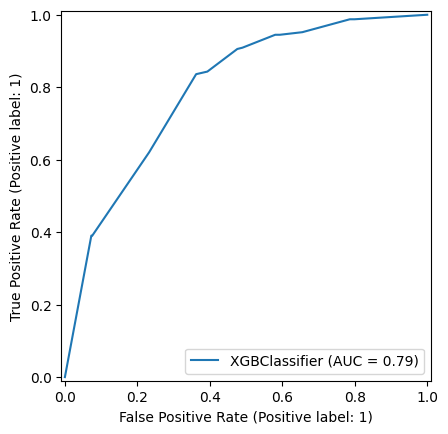

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score, RocCurveDisplay

print(classification_report(y_test, preds))
print(f"AUC-ROC: {roc_auc_score(y_test, preds):.3f}")

RocCurveDisplay.from_estimator(bst, X_test, y_test)

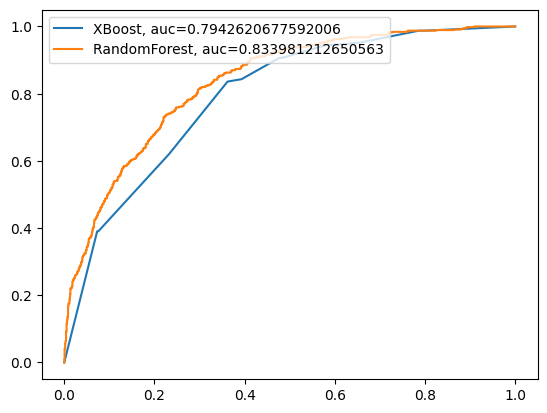

In [ ]:
from sklearn import metrics

y_pred_probability = bst.predict_proba(X_test)[::,1]
fpr, tpr, _ = metrics.roc_curve(y_test,  y_pred_probability)
auc = metrics.roc_auc_score(y_test, y_pred_probability)
plt.plot(fpr,tpr,label="XBoost, auc="+str(auc))
plt.legend(loc=2)

y_pred_probability = grid_search.predict_proba(X_test)[::,1]
fpr, tpr, _ = metrics.roc_curve(y_test,  y_pred_probability)
auc = metrics.roc_auc_score(y_test, y_pred_probability)
plt.plot(fpr,tpr,label="RandomForest, auc="+str(auc))
plt.legend(loc=2)
plt.show()


O Random Forest têm uma curva ROC mais suave , indicando uma distribuição de probabilidades mais contínua, enquanto a curva ROC do modelo XBoost tem algumas partes mais pontudas , indicando que o modelo gera menos variações de probabilidades.
O melhor modelo para este problema de previsão de churn é o Random Forest após o ajuste de hiperparâmetros com GridSearchCV.